# Topic and Category Quality Report

This notebook evaluates AI-generated topics and assigned categories from Mongo `youtube_channel_videos`.

## Outputs
- Coverage and distribution metrics
- Topic/category summaries
- Redundancy and consistency checks
- Co-occurrence diagnostics
- CSV exports for supervisor reporting

In [ ]:
# Optional one-time dependency bootstrap (run only if imports fail).
import sys
!{sys.executable} -m pip install pymongo neo4j scikit-learn openai python-dotenv pandas numpy matplotlib

In [1]:
import os
from collections import Counter

import numpy as np  # pyright: ignore[reportMissingImports]
import pandas as pd  # pyright: ignore[reportMissingImports]
import matplotlib.pyplot as plt  # pyright: ignore[reportMissingImports]
from pymongo import MongoClient  # pyright: ignore[reportMissingImports]
from sklearn.feature_extraction.text import TfidfVectorizer  # pyright: ignore[reportMissingImports]
from sklearn.metrics.pairwise import cosine_similarity  # pyright: ignore[reportMissingImports]

try:
    from dotenv import load_dotenv  # pyright: ignore[reportMissingImports]
    load_dotenv(".env")
except Exception:
    pass

MONGODB_URI = os.getenv("MONGODB_URI")
MONGODB_DB = os.getenv("MONGODB_DB", "rbl")
MONGO_VIDEOS_COLLECTION = os.getenv("MONGO_VIDEOS_COLLECTION", "youtube_channel_videos")

# Output directory for report artifacts.
OUTPUT_DIR = os.getenv("TOPIC_REPORT_OUTPUT_DIR", "/opt/airflow/notebooks/outputs/topic_quality_report")
os.makedirs(OUTPUT_DIR, exist_ok=True)

if not MONGODB_URI:
    raise ValueError("Set MONGODB_URI in environment first.")

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 140)
print("output dir:", OUTPUT_DIR)

output dir: /opt/airflow/notebooks/outputs/topic_quality_report


In [2]:
# Load video documents from Mongo.
mongo = MongoClient(MONGODB_URI)
coll = mongo[MONGODB_DB][MONGO_VIDEOS_COLLECTION]

query = {"video_id": {"$exists": True, "$nin": [None, ""]}}
projection = {
    "_id": 0,
    "video_id": 1,
    "channel_title": 1,
    "comments_analysis_model": 1,
    "comments_analyzed_at": 1,
    "comments_count_relevance": 1,
    "comments_frequent_topics": 1,
    "comments_frequent_topic_categories": 1,
    "comments_frequent_topic_weights": 1,
}

docs = list(coll.find(query, projection=projection))
mongo.close()

videos_df = pd.DataFrame(docs)
if "comments_count_relevance" not in videos_df.columns:
    videos_df["comments_count_relevance"] = 0
videos_df["comments_count_relevance"] = pd.to_numeric(videos_df["comments_count_relevance"], errors="coerce").fillna(0).astype(int)

videos_with_topics = videos_df["comments_frequent_topics"].apply(lambda x: isinstance(x, list) and len(x) > 0)
videos_topics_df = videos_df.loc[videos_with_topics].copy()
videos_with_relevance = videos_topics_df["comments_count_relevance"] > 0

print("videos loaded (all):", len(videos_df))
print("videos in report scope (with topics):", len(videos_topics_df))
print("scope videos with comments_count_relevance > 0:", int(videos_with_relevance.sum()))
print("scope videos with comments_count_relevance = 0:", int((~videos_with_relevance).sum()))

/tmp/ipykernel_1188/827753020.py:2: UserWarning: You appear to be connected to a CosmosDB cluster. For more information regarding feature compatibility and support please visit https://www.mongodb.com/supportability/cosmosdb
  mongo = MongoClient(MONGODB_URI)


videos loaded (all): 25803
videos in report scope (with topics): 6693
scope videos with comments_count_relevance > 0: 6693
scope videos with comments_count_relevance = 0: 0


In [3]:
# Flatten per-video arrays to row-level topic records.
rows = []
for _, r in videos_topics_df.iterrows():
    video_id = str(r.get("video_id", "")).strip()
    if not video_id:
        continue

    topics = r.get("comments_frequent_topics") or []
    cats = r.get("comments_frequent_topic_categories") or []
    weights = r.get("comments_frequent_topic_weights") or []

    if not isinstance(topics, list):
        continue

    for i, t in enumerate(topics):
        topic = str(t or "").strip()
        if not topic:
            continue

        cat = str(cats[i] if isinstance(cats, list) and i < len(cats) else "").strip()
        try:
            w = float(weights[i]) if isinstance(weights, list) and i < len(weights) else 0.0
        except Exception:
            w = 0.0

        rows.append(
            {
                "video_id": video_id,
                "channel_title": r.get("channel_title"),
                "model": r.get("comments_analysis_model"),
                "analyzed_at": r.get("comments_analyzed_at"),
                "comments_count_relevance": int(r.get("comments_count_relevance") or 0),
                "topic": topic,
                "category": cat if cat else "<missing>",
                "weight": w,
            }
        )

topic_rows = pd.DataFrame(rows)
print("flattened topic rows:", len(topic_rows))
print("unique topics:", topic_rows["topic"].nunique())
print("unique categories:", topic_rows["category"].nunique())
print("min comments_count_relevance in analysis set:", int(topic_rows["comments_count_relevance"].min()) if not topic_rows.empty else 0)
topic_rows.head(5)

flattened topic rows: 54115
unique topics: 44089
unique categories: 6591
min comments_count_relevance in analysis set: 1


,video_id,channel_title,model,analyzed_at,comments_count_relevance,topic,category,weight
0,K_CbgLpvH9E,MrBeast,gpt-4.1,2026-03-03 16:44:31.413,1000,Solitary Confinement Challenge,Challenge,1.00
1,K_CbgLpvH9E,MrBeast,gpt-4.1,2026-03-03 16:44:31.413,1000,"""67"" Meme and Time References",Humor,0.65
2,K_CbgLpvH9E,MrBeast,gpt-4.1,2026-03-03 16:44:31.413,1000,Mental Health and Sanity,Well-being,0.41
3,K_CbgLpvH9E,MrBeast,gpt-4.1,2026-03-03 16:44:31.413,1000,"""I'm Batman"" Joke",Humor,0.33
4,K_CbgLpvH9E,MrBeast,gpt-4.1,2026-03-03 16:44:31.413,1000,Creativity in Isolation,Coping Strategies,0.23


In [15]:
# 1) Descriptive metrics.
covered_videos = topic_rows["video_id"].nunique()
all_videos = videos_topics_df["video_id"].nunique()
coverage = covered_videos / all_videos if all_videos else 0.0

per_video_topic_count = topic_rows.groupby("video_id")["topic"].count().rename("topics_per_video")
avg_topics_per_video = float(per_video_topic_count.mean()) if len(per_video_topic_count) else 0.0

# Per-video category volume (unique categories per video).
per_video_category_count = topic_rows.groupby("video_id")["category"].nunique().rename("categories_per_video")
avg_categories_per_video = float(per_video_category_count.mean()) if len(per_video_category_count) else 0.0

topic_stats = (
    topic_rows.groupby("topic", as_index=False)
    .agg(
        videos_count=("video_id", "nunique"),
        total_weight=("weight", "sum"),
        mean_weight=("weight", "mean"),
    )
    .sort_values("total_weight", ascending=False)
)

category_stats = (
    topic_rows.groupby("category", as_index=False)
    .agg(
        videos_count=("video_id", "nunique"),
        rows_count=("topic", "count"),
        total_weight=("weight", "sum"),
    )
    .sort_values("total_weight", ascending=False)
)

print(f"coverage (videos with topics): {covered_videos}/{all_videos} ({coverage:.2%})")
print("average topics/video:", round(avg_topics_per_video, 2))
print("median topics/video:", per_video_topic_count.median())
print("p90 topics/video:", per_video_topic_count.quantile(0.90))
print("average categories/video:", round(avg_categories_per_video, 2))
print("median categories/video:", per_video_category_count.median())
print("p90 categories/video:", per_video_category_count.quantile(0.90))
print("\nTop topics by total_weight")
display(topic_stats.head(20))
print("\nTop categories by total_weight")
display(category_stats.head(20))

coverage (videos with topics): 6693/6693 (100.00%)
average topics/video: 8.09
median topics/video: 8.0
p90 topics/video: 10.0
average categories/video: 7.19
median categories/video: 7.0
p90 categories/video: 10.0

Top topics by total_weight


,topic,videos_count,total_weight,mean_weight
17994,Humor and Laughter,161,51.79,0.321677
32632,Requests for More Content,141,23.75,0.168440
13667,Fortnite Gameplay,84,22.00,0.261905
18015,Humor and Memes,121,19.71,0.162893
21036,Laughter and Humor,46,18.03,0.391957
1120,Among Us Mods,28,16.51,0.589643
17960,Humor and Entertainment,60,16.45,0.274167
29039,Positive Feedback,87,15.33,0.176207
39966,Touzani,32,13.35,0.417187
41021,Video Appreciation,68,13.34,0.196176



Top categories by total_weight


,category,videos_count,rows_count,total_weight
925,Community,2869,3695,570.590
1920,Entertainment,1925,2093,439.760
2745,Gaming,705,920,229.310
1904,Engagement,1310,1503,227.010
1151,Content,767,922,198.580
2651,Gameplay,459,614,153.970
1421,Creator,483,518,149.430
5088,Relationships,509,604,147.010
3159,Humor,660,734,145.970
4533,Personality,478,579,145.910


In [5]:
# 1b) Simple lexical normalization for topic-label fragmentation.
import re


def normalize_topic_label(topic: str) -> str:
    """Build a lightweight canonical key from a topic label.

    This is intentionally lexical (not embedding-based): lowercase, strip punctuation,
    drop common connector words, singularize simple plurals, and sort tokens so
    reorderings like 'Humor and Laughter' / 'Laughter and Humor' collapse together.
    """
    if not isinstance(topic, str):
        return "<missing>"

    text = topic.lower().strip()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    tokens = [t for t in text.split() if t]

    # Drop weak connector tokens that do not carry topic meaning.
    stop_tokens = {
        "and", "or", "the", "a", "an", "of", "for", "to", "in", "on", "with", "about"
    }

    cleaned = []
    for t in tokens:
        if t in stop_tokens:
            continue
        # Naive singularization for simple plural forms.
        if len(t) > 3 and t.endswith("s") and not t.endswith("ss"):
            t = t[:-1]
        cleaned.append(t)

    if not cleaned:
        return "<empty>"

    return " ".join(sorted(set(cleaned)))


topic_rows_norm = topic_rows.copy()
topic_rows_norm["topic_norm_key"] = topic_rows_norm["topic"].apply(normalize_topic_label)

raw_unique_topics = int(topic_rows_norm["topic"].nunique())
norm_unique_topics = int(topic_rows_norm["topic_norm_key"].nunique())

norm_topic_stats = (
    topic_rows_norm.groupby("topic_norm_key", as_index=False)
    .agg(
        videos_count=("video_id", "nunique"),
        total_weight=("weight", "sum"),
        mean_weight=("weight", "mean"),
        raw_topic_labels=("topic", lambda s: sorted(set(s))),
    )
    .sort_values("total_weight", ascending=False)
)

norm_topic_stats["raw_label_count"] = norm_topic_stats["raw_topic_labels"].apply(len)
norm_topic_stats["example_labels"] = norm_topic_stats["raw_topic_labels"].apply(lambda xs: "; ".join(xs[:5]))

print("raw unique topics:", raw_unique_topics)
print("normalized topic keys:", norm_unique_topics)
if raw_unique_topics > 0:
    print("reduction:", f"{(1 - norm_unique_topics / raw_unique_topics):.2%}")

print("\nTop normalized topics by total_weight")
display(norm_topic_stats[["topic_norm_key", "videos_count", "total_weight", "mean_weight", "raw_label_count", "example_labels"]].head(20))

print("\nMost fragmented normalized keys (many raw labels merged)")
display(norm_topic_stats.sort_values("raw_label_count", ascending=False)[["topic_norm_key", "raw_label_count", "example_labels", "videos_count", "total_weight"]].head(20))

raw unique topics: 44089
normalized topic keys: 39714
reduction: 9.92%

Top normalized topics by total_weight


,topic_norm_key,videos_count,total_weight,mean_weight,raw_label_count,example_labels
32548,humor laughter,233,74.13,0.318155,9,Humor & Laughter; Humor & laughter; Humor and Laughter; Humor and laughter; Humor/Laughter
19119,content more request,152,25.41,0.167171,5,More Content Requests; Request for More Content; Requests For More Content; Requests for More Content; Requests for more content
29541,funny humor moment,105,25.06,0.238667,10,Funny Moments & Humor; Funny Moments / Humor; Funny Moments and Humor; Funny Moments/Humor; Funny moments and humor
32576,humor meme,164,24.99,0.152378,6,Humor & Memes; Humor and Memes; Humor and memes; Humor/Memes; Humor/memes
28934,fortnite gameplay,96,24.24,0.252500,3,Fortnite Gameplay; Fortnite gameplay; Gameplay (Fortnite)
25418,entertainment humor,79,19.65,0.248734,6,Entertainment and Humor; Entertainment and humor; Humor & Entertainment; Humor and Entertainment; Humor and entertainment
32519,humor joke,132,18.91,0.143258,8,Humor & Jokes; Humor and Jokes; Humor and jokes; Humor/Jokes; Humor/jokes
27891,feedback positive,94,16.83,0.179043,2,Positive Feedback; Positive feedback
3672,among mod us,30,16.76,0.558667,3,Among Us Mod; Among Us Mods; Among Us and Mods
36692,more request video,80,16.49,0.206125,4,Request for More Videos; Request for more videos; Requests for More Videos; Requests for more videos



Most fragmented normalized keys (many raw labels merged)


,topic_norm_key,raw_label_count,example_labels,videos_count,total_weight
19235,content quality vlog,17,Vlog Content & Quality; Vlog Content Quality; Vlog Content and Quality; Vlog Content/Quality; Vlog Quality & Content,70,12.62
23725,dynamic friendship group,13,Friendship & Group Dynamics; Friendship and Group Dynamic; Friendship and Group Dynamics; Friendship and group dynamic; Friendship and g...,49,13.02
27908,feedback positive video,12,Positive Feedback about Videos; Positive Feedback about the Video; Positive Feedback for Videos; Positive Feedback on Video; Positive Fe...,26,4.01
5363,appreciation fan support,11,Appreciation/Fan Support; Fan Appreciation & Support; Fan Appreciation and Support; Fan Appreciation/Support; Fan Support & Appreciation,64,11.93
36917,music request song,11,Music & Song Requests; Music / Song Requests; Music Song Requests; Music and Song Requests; Music/Song Requests,35,5.12
18797,content feedback vlog,10,Content and Vlog Feedback; Feedback on Vlog Content; Vlog Content & Feedback; Vlog Content Feedback; Vlog Content and Feedback,17,1.21
29541,funny humor moment,10,Funny Moments & Humor; Funny Moments / Humor; Funny Moments and Humor; Funny Moments/Humor; Funny moments and humor,105,25.06
23712,dynamic friend group,9,Friend Group Dynamics; Friend Group/Dynamics; Friend group dynamics; Friend/Group Dynamics; Friends and Group Dynamic,24,4.52
5605,appreciation support viewer,9,Viewer Appreciation & Support; Viewer Appreciation and Support; Viewer Appreciation/Support; Viewer Support & Appreciation; Viewer Suppo...,47,6.97
38962,request subtitle translation,9,Requests for Subtitles or Translation; Requests for Subtitles/Translation; Requests for Subtitles/Translations; Requests for Translation...,17,3.54


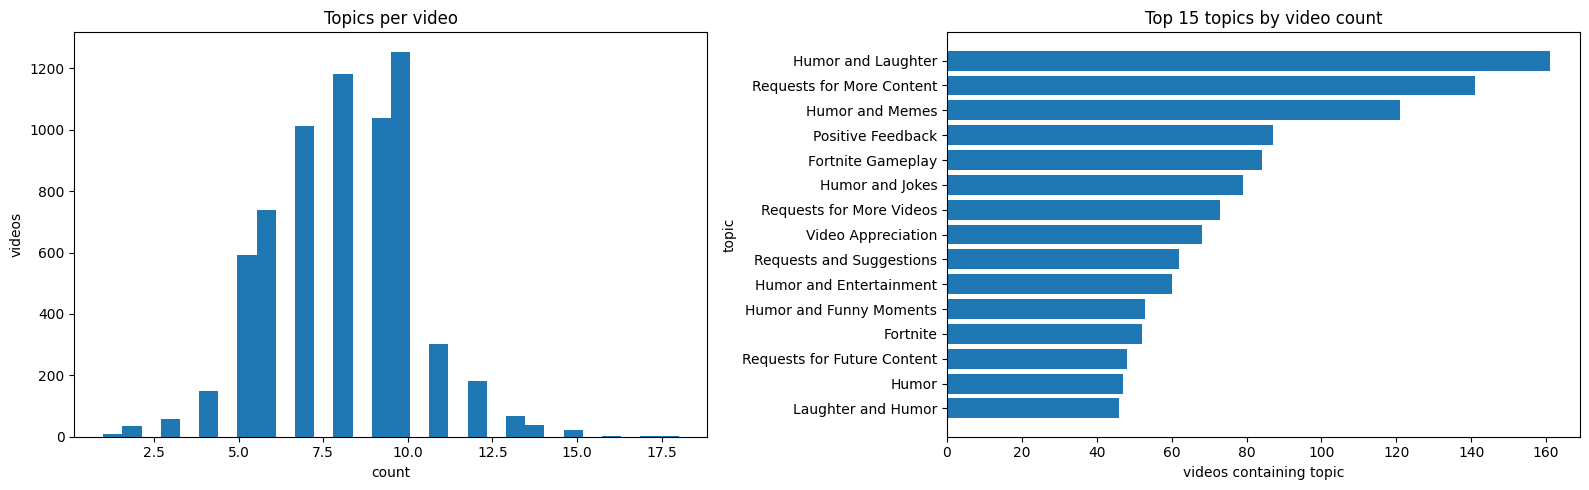

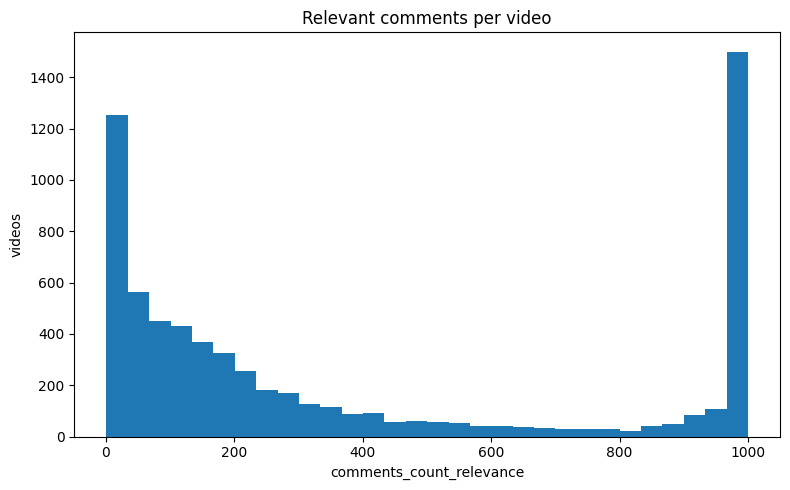

comments_count_relevance summary


count    6693.000000
mean      388.188555
std       391.203505
min         1.000000
10%        16.000000
25%        58.000000
50%       195.000000
75%       908.000000
90%      1000.000000
max      1000.000000
Name: comments_count_relevance, dtype: float64

saved standalone plot: /opt/airflow/notebooks/outputs/topic_quality_report/relevant_comments_per_video.png


In [16]:
# 2) Distribution plots (simplified).
# Keep "Relevant comments per video" as a separate standalone figure for reporting/slides.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(per_video_topic_count.values, bins=30)
axes[0].set_title("Topics per video")
axes[0].set_xlabel("count")
axes[0].set_ylabel("videos")

# Easier-to-read alternative to log-log long-tail.
top_topics = (
    topic_rows.groupby("topic")["video_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(15)
    .sort_values(ascending=True)
)
axes[1].barh(top_topics.index, top_topics.values)
axes[1].set_title("Top 15 topics by video count")
axes[1].set_xlabel("videos containing topic")
axes[1].set_ylabel("topic")

plt.tight_layout()
plt.show()

# Standalone chart: how many relevant comments each processed video has.
# Keep population consistent with topic analysis: only videos that have topics.
comment_counts = videos_topics_df["comments_count_relevance"].dropna()

fig2, ax2 = plt.subplots(figsize=(8, 5))
ax2.hist(comment_counts.values, bins=30)
ax2.set_title("Relevant comments per video")
ax2.set_xlabel("comments_count_relevance")
ax2.set_ylabel("videos")
plt.tight_layout()

# Save slide-ready standalone image.
standalone_path = os.path.join(OUTPUT_DIR, "relevant_comments_per_video.png")
fig2.savefig(standalone_path, dpi=180, bbox_inches="tight")
plt.show()

print("comments_count_relevance summary")
display(comment_counts.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]))
print("saved standalone plot:", standalone_path)

In [7]:
# 3) Overall entropy summary (all scoped videos with topics)
def shannon_entropy(ws):
    arr = np.array(ws, dtype=float)
    arr = arr[arr > 0]
    if arr.size == 0:
        return 0.0
    p = arr / arr.sum()
    return float(-(p * np.log2(p)).sum())

video_entropy = (
    topic_rows.groupby("video_id")["weight"]
    .apply(shannon_entropy)
    .rename("topic_entropy")
)

print("Entropy summary")
display(video_entropy.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]))

Entropy summary


count    6693.000000
mean        2.666814
std         0.439613
min        -0.000000
10%         2.152569
25%         2.421140
50%         2.710139
75%         2.977700
90%         3.157526
max         3.969465
Name: topic_entropy, dtype: float64

Entropy by comments_count_relevance bucket


,comment_bucket,videos,mean_entropy,median_entropy,p10,p90
0,1-10,425,1.919120,2.000000,1.000000,2.399309
1,11-50,1129,2.396756,2.407345,2.078700,2.736635
2,51-200,1841,2.702424,2.719220,2.332660,3.057991
3,200+,3298,2.835738,2.894407,2.356049,3.244573


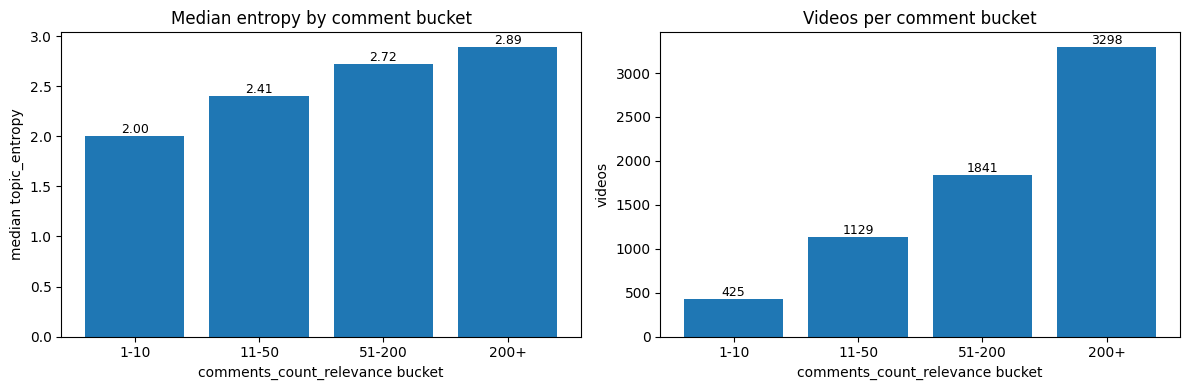

In [8]:
# 3b) Topic diversity by relevant-comment-count bucket.
# Helps interpret whether low topic diversity is evidence of focus or just low sample size.

per_video_comments = (
    topic_rows.groupby("video_id")["comments_count_relevance"]
    .max()
    .rename("comments_count_relevance")
)

entropy_with_comments = pd.concat([video_entropy, per_video_comments], axis=1).dropna()

bins = [0, 10, 50, 200, np.inf]
labels = ["1-10", "11-50", "51-200", "200+"]
entropy_with_comments["comment_bucket"] = pd.cut(
    entropy_with_comments["comments_count_relevance"],
    bins=bins,
    labels=labels,
    include_lowest=True,
)

bucket_summary = (
    entropy_with_comments.groupby("comment_bucket", observed=True)["topic_entropy"]
    .agg(
        videos="count",
        mean_diversity="mean",
        median_diversity="median",
        p10=lambda s: s.quantile(0.10),
        p90=lambda s: s.quantile(0.90),
    )
    .reset_index()
)

print("Topic diversity by comments_count_relevance bucket")
display(bucket_summary)

# Simpler visualization: median topic diversity + sample size per bucket.
plot_df = bucket_summary.copy()
plot_df["comment_bucket"] = pd.Categorical(plot_df["comment_bucket"], categories=labels, ordered=True)
plot_df = plot_df.sort_values("comment_bucket")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(plot_df["comment_bucket"].astype(str), plot_df["median_diversity"])
axes[0].set_title("Median topic diversity by comment bucket")
axes[0].set_xlabel("comments_count_relevance bucket")
axes[0].set_ylabel("median topic diversity")
for i, v in enumerate(plot_df["median_diversity"]):
    axes[0].text(i, v + 0.03, f"{v:.2f}", ha="center", fontsize=9)

axes[1].bar(plot_df["comment_bucket"].astype(str), plot_df["videos"])
axes[1].set_title("Videos per comment bucket")
axes[1].set_xlabel("comments_count_relevance bucket")
axes[1].set_ylabel("videos")
for i, v in enumerate(plot_df["videos"]):
    axes[1].text(i, v + max(plot_df["videos"]) * 0.01, f"{int(v)}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

low-entropy threshold: 2.1526
videos in focused subset: 670
focused subset comments_count_relevance summary


count     670.000000
mean      197.422388
std       323.190123
min         1.000000
10%         3.000000
25%         6.000000
50%        21.000000
75%       220.000000
90%       922.100000
max      1000.000000
Name: comments_count_relevance, dtype: float64

focused subset by comments_count_relevance bucket


,videos
comment_bucket,
1-10,238
11-50,177
51-100,31
101-300,80
301-600,48
601-1000,96


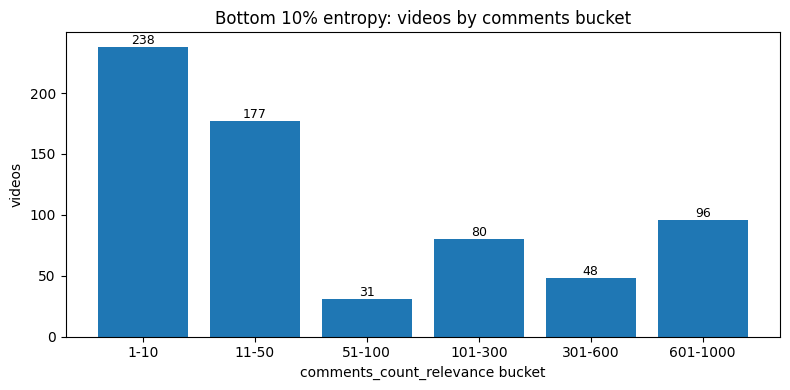


Bucket 1-10 - videos: 238


dominant_topic
Humor                    7
Livestream Enjoyment     5
Positive Feedback        4
Stream Enjoyment         3
Roy                      3
Appreciation             2
Laughter and Humor       2
Feyenoord Performance    2
Humor and Laughter       2
Livestream Quality       2
Name: count, dtype: int64

dominant_category
Engagement       24
Sports           15
Entertainment    11
Gaming            8
Feedback          7
Emotion           7
Community         6
Personality       5
Gameplay          4
Content           4
Name: count, dtype: int64


Bucket 11-50 - videos: 177


dominant_topic
Humor and Laughter             9
Feyenoord Support              7
Laughter and Humor             5
Fortnite                       3
Match Predictions              3
Humor                          3
Feyenoord Support and Pride    2
Playing Together               2
Positive Stream Feedback       2
Roy                            2
Name: count, dtype: int64

...

dominant_topic
Birthday and Earned Amount                                           1
Tremors Comparison                                                   1
Birthday Congratulations                                             1
Stray Kids fandom                                                    1
"We friends tho" / Tyla friendzone moment                            1
Personal Records / Times                                             1
Counting Number of People (Four)                                     1
Bicep                                                                1
Paranormal Occurrences (moving objects, faces in windows, noises)    1
Sigils is bald                                                       1
Name: count, dtype: int64

dominant_category
Humor                 3
Celebration           3
Game/Challenge        2
Engagement            2
Gameplay              2
Meme                  2
DIY & Home            1
Animation Error       1
Community             1
Supermarket Prices    1
Name: count, dtype: int64

,video_id,dominant_topic,dominant_category,dominant_weight,comments_count_relevance,comment_bucket
16,05yD3zXhV8E,Winning Against PSV,Sports Outcome,1.0,1,1-10
27,1Kz1XZSrufg,First Comment,Engagement,1.0,1,1-10
48,32uOv9wFXAo,HPF Vibes,Nostalgia,1.0,1,1-10
278,QCWWjls9l-s,Appreciation,Positive Feedback,1.0,1,1-10
311,Sp4eMHnJ4KI,Low Quality,Criticism,1.0,1,1-10
539,naZ2SKylP-g,Celebration,Emotion,1.0,1,1-10
638,wD_DszqzEgQ,Dordrecht's Chances,Match Prediction,1.0,1,1-10
646,xSNYVK1hsOc,Sparta's Performance,Sports,1.0,1,1-10
649,xarGZHcL3Hg,Affection for Nijntje,Character Inquiry,1.0,1,1-10
51,3NBlC5O39nM,Lack of Feyenoord Chances,Match Analysis,0.7,1,1-10


dominant_topic
Humor and Laughter            11
Laughter and Humor            10
Humor                         10
Feyenoord Support              9
Livestream Enjoyment           6
Positive Feedback              5
Roy                            5
Match Predictions              3
Stream Enjoyment               3
More Among Us videos           3
Fortnite                       3
Greetings                      3
More vlogs                     2
Feyenoord Performance          2
Livestream Quality             2
500k Subscribers Milestone     2
Celebration                    2
Song Identification            2
Roy's Laugh                    2
Enjoyment                      2
Name: count, dtype: int64

dominant_category
Entertainment           36
Engagement              35
Humor                   21
Gaming                  19
Sports                  18
Community               17
Gameplay                12
Personality             12
Emotion                  9
Music                    8
Feedback                 8
Celebration              8
Content                  7
Community Engagement     7
Creator                  7
Player Performance       6
Food                     6
Support                  5
Vehicles                 5
Team Support             5
Name: count, dtype: int64

In [9]:
# Join entropy with topic rows and find dominant topic per low-entropy videos.
# Includes comments_count_relevance and granular buckets for evidence-strength context.
low_thr = video_entropy.quantile(0.10)  # bottom 10% entropy
low_entropy_videos = set(video_entropy[video_entropy <= low_thr].index)

per_video_comments = (
    topic_rows.groupby("video_id")["comments_count_relevance"]
    .max()
    .rename("comments_count_relevance")
    .reset_index()
)

dominant = (
    topic_rows[topic_rows["video_id"].isin(low_entropy_videos)]
    .sort_values(["video_id", "weight"], ascending=[True, False])
    .groupby("video_id", as_index=False)
    .first()[["video_id", "topic", "category", "weight"]]
    .rename(columns={"topic": "dominant_topic", "category": "dominant_category", "weight": "dominant_weight"})
    .merge(per_video_comments, on="video_id", how="left")
)

print("low-entropy threshold:", round(float(low_thr), 4))
print("videos in focused subset:", len(dominant))
print("focused subset comments_count_relevance summary")
display(dominant["comments_count_relevance"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]))

focus_bins = [0, 10, 50, 100, 300, 600, 1000]
focus_labels = ["1-10", "11-50", "51-100", "101-300", "301-600", "601-1000"]

dominant["comment_bucket"] = pd.cut(
    dominant["comments_count_relevance"],
    bins=focus_bins,
    labels=focus_labels,
    include_lowest=True,
)
focus_bucket_counts = dominant["comment_bucket"].value_counts().reindex(focus_labels, fill_value=0)

print("focused subset by comments_count_relevance bucket")
display(focus_bucket_counts.rename("videos").to_frame())

plt.figure(figsize=(8, 4))
bars = plt.bar(focus_bucket_counts.index.astype(str), focus_bucket_counts.values)
plt.title("Bottom 10% entropy: videos by comments bucket")
plt.xlabel("comments_count_relevance bucket")
plt.ylabel("videos")
for b, v in zip(bars, focus_bucket_counts.values):
    plt.text(b.get_x() + b.get_width() / 2, v + max(focus_bucket_counts.values.tolist() + [1]) * 0.01, f"{int(v)}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

for b in focus_labels:
    d = dominant[dominant["comment_bucket"] == b]
    if d.empty:
        continue
    print(f"\nBucket {b} - videos: {len(d)}")
    display(d["dominant_topic"].value_counts().head(10))
    display(d["dominant_category"].value_counts().head(10))

display(dominant.sort_values(["comments_count_relevance", "dominant_weight"], ascending=[True, False]).head(30))
display(dominant["dominant_topic"].value_counts().head(20))
display(dominant["dominant_category"].value_counts().head(20))

In [10]:
# 4) Redundancy and category consistency proxy via label similarity (ultra-light).
# This version is intentionally conservative to avoid kernel crashes.
if "topic_rows" not in globals():
    raise RuntimeError("topic_rows is not defined. Run the flatten-topics cell first.")

from sklearn.neighbors import NearestNeighbors  # pyright: ignore[reportMissingImports]

unique_topics = topic_rows[["topic", "category"]].drop_duplicates(subset=["topic"]).reset_index(drop=True)
full_n_topics = len(unique_topics)

# Limit analysis to a random topic sample so memory/runtime stays bounded.
sample_topics_n = 8000
sampled_topics = unique_topics.sample(n=min(sample_topics_n, full_n_topics), random_state=42).reset_index(drop=True)

vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=2, max_features=80000)
X = vec.fit_transform(sampled_topics["topic"])
n_topics = X.shape[0]

near_dup_threshold = 0.85
max_neighbors = 8
k = min(max_neighbors, n_topics)

# 4a) Approx near-duplicate detection on sampled topics only.
if k <= 1:
    near_dup_df = pd.DataFrame(columns=["topic_a", "cat_a", "topic_b", "cat_b", "similarity"])
else:
    nn = NearestNeighbors(metric="cosine", algorithm="brute", n_neighbors=k)
    nn.fit(X)
    distances, indices = nn.kneighbors(X)

    seen_pairs = set()
    near_dup_rows = []
    for i in range(n_topics):
        for rank in range(1, k):  # rank 0 is self
            j = int(indices[i, rank])
            sim = 1.0 - float(distances[i, rank])
            if sim < near_dup_threshold:
                continue
            a, b = (i, j) if i < j else (j, i)
            if a == b or (a, b) in seen_pairs:
                continue
            seen_pairs.add((a, b))
            near_dup_rows.append(
                {
                    "topic_a": sampled_topics.loc[a, "topic"],
                    "cat_a": sampled_topics.loc[a, "category"],
                    "topic_b": sampled_topics.loc[b, "topic"],
                    "cat_b": sampled_topics.loc[b, "category"],
                    "similarity": sim,
                }
            )

    near_dup_df = pd.DataFrame(near_dup_rows)
    if len(near_dup_df):
        near_dup_df = near_dup_df.sort_values("similarity", ascending=False).reset_index(drop=True)

print(f"topics total: {full_n_topics}, sampled: {n_topics}, neighbors per topic: {k}")
print("near-duplicate topic pairs (>=0.85) in sample:", len(near_dup_df))
display(near_dup_df.head(30))

# 4b) Category consistency from sampled pairs (sampled topics only).
rng = np.random.default_rng(42)
cat_vals = sampled_topics["category"].to_numpy()
cat_to_idx = sampled_topics.groupby("category").indices

sample_pairs_target = 5000

within_pairs = set()
valid_cats = [c for c, idx in cat_to_idx.items() if len(idx) >= 2]
attempts = 0
max_attempts = sample_pairs_target * 40
while len(within_pairs) < sample_pairs_target and attempts < max_attempts and valid_cats:
    c = valid_cats[int(rng.integers(0, len(valid_cats)))]
    idx = np.asarray(cat_to_idx[c], dtype=int)
    i, j = rng.choice(idx, size=2, replace=False)
    a, b = (int(i), int(j)) if i < j else (int(j), int(i))
    within_pairs.add((a, b))
    attempts += 1

between_pairs = set()
attempts = 0
all_idx = np.arange(n_topics)
while len(between_pairs) < sample_pairs_target and attempts < max_attempts and n_topics >= 2:
    i, j = rng.choice(all_idx, size=2, replace=False)
    if cat_vals[i] == cat_vals[j]:
        attempts += 1
        continue
    a, b = (int(i), int(j)) if i < j else (int(j), int(i))
    between_pairs.add((a, b))
    attempts += 1


def pair_sims_from_index_pairs(X_sparse, pair_set):
    if not pair_set:
        return np.array([], dtype=float)
    pair_arr = np.array(list(pair_set), dtype=int)
    a_idx = pair_arr[:, 0]
    b_idx = pair_arr[:, 1]
    sims = X_sparse[a_idx].multiply(X_sparse[b_idx]).sum(axis=1).A1
    return sims.astype(float)

within = pair_sims_from_index_pairs(X, within_pairs)
between = pair_sims_from_index_pairs(X, between_pairs)

print("within sample pairs:", len(within), "between sample pairs:", len(between))
print("avg within-category similarity (sample):", round(float(np.mean(within)) if len(within) else 0.0, 4))
print("avg between-category similarity (sample):", round(float(np.mean(between)) if len(between) else 0.0, 4))

topics total: 44089, sampled: 8000, neighbors per topic: 8
near-duplicate topic pairs (>=0.85) in sample: 386


,topic_a,cat_a,topic_b,cat_b,similarity
0,Baby and pregnancy,Personal Life,Baby and Pregnancy,Family,1.0
1,Friendship and Support,Community,Support and Friendship,Relationships,1.0
2,Animation style and art,Content,Animation Style and Art,Animation,1.0
3,Fan Love and Support,Community,Fan support and love,Fandom,1.0
4,Fan Appreciation and Interaction,Community,Fan appreciation and interaction,Community,1.0
5,Congratulations & Compliments,Community Support,Compliments & Congratulations,Support,1.0
6,Video Production and Editing,Production Quality,Editing and Video Production,Production,1.0
7,Community and Fan Support,Community,Fan Support and Community,Community,1.0
8,Food and recipes,Daily Life,Food and Recipes,Lifestyle,1.0
9,Positive Feedback and Video Appreciation,Audience Engagement,Video appreciation and positive feedback,Engagement,1.0


within sample pairs: 5000 between sample pairs: 5000
avg within-category similarity (sample): 0.0771
avg between-category similarity (sample): 0.0125


In [11]:
# 5) Co-occurrence diagnostics.
def top_cooccurrence_pairs(df, col, top_n=30):
    counts = Counter()
    for _, g in df.groupby("video_id"):
        vals = sorted(set(str(v).strip() for v in g[col].dropna().tolist() if str(v).strip()))
        for i in range(len(vals)):
            for j in range(i + 1, len(vals)):
                counts[(vals[i], vals[j])] += 1
    out = pd.DataFrame([
        {"a": a, "b": b, "cooccur_videos": c} for (a, b), c in counts.most_common(top_n)
    ])
    return out

print("Top topic co-occurrence pairs")
display(top_cooccurrence_pairs(topic_rows, "topic", top_n=25))

print("Top category co-occurrence pairs")
display(top_cooccurrence_pairs(topic_rows, "category", top_n=25))

Top topic co-occurrence pairs


,a,b,cooccur_videos
0,Humor and Laughter,Requests for More Content,13
1,Humor and Funny Moments,Requests for More Content,7
2,Ronaldo vs Messi,Stream Endings,7
3,Fortnite Gameplay,Streamer Appreciation,7
4,Humor and Laughter,Requests for More Videos,7
5,Among Us Mods,Nostalgia for Old Content,6
6,Funny Moments,Positive Feedback,5
7,Animation and Art Style,MSA Appreciation,5
8,Fortnite,Rocket League,5
9,Animation and Art Style,MSA Channel Appreciation,5


Top category co-occurrence pairs


,a,b,cooccur_videos
0,Community,Entertainment,931
1,Community,Engagement,674
2,Community,Content,472
3,Community,Gaming,419
4,Engagement,Entertainment,360
5,Community,Lifestyle,339
6,Community,Feedback,333
7,Community,Creator,280
8,Community,Humor,275
9,Community,Sentiment,267


In [13]:
# 7) Compact metrics export for report deck.
report_rows = [
    {"metric": "scope_videos_with_topics", "value": int(all_videos)},
    {"metric": "videos_with_topic_rows", "value": int(covered_videos)},
    {"metric": "coverage_ratio_within_topic_scope", "value": float(coverage)},
    {"metric": "topic_rows", "value": int(len(topic_rows))},
    {"metric": "unique_topics", "value": int(topic_rows["topic"].nunique())},
    {"metric": "unique_categories", "value": int(topic_rows["category"].nunique())},
    {"metric": "median_topics_per_video", "value": float(per_video_topic_count.median())},
    {"metric": "p90_topics_per_video", "value": float(per_video_topic_count.quantile(0.90))},
    {"metric": "avg_within_category_similarity", "value": float(np.mean(within)) if len(within) else 0.0},
    {"metric": "avg_between_category_similarity", "value": float(np.mean(between)) if len(between) else 0.0},
    {"metric": "near_duplicate_pairs_ge_0.85", "value": int(len(near_dup_df))},
]

report_df = pd.DataFrame(report_rows)
report_path = os.path.join(OUTPUT_DIR, "topic_quality_report_metrics.csv")
report_df.to_csv(report_path, index=False)
print("saved metrics csv:", report_path)
display(report_df)

saved metrics csv: /opt/airflow/notebooks/outputs/topic_quality_report/topic_quality_report_metrics.csv


,metric,value
0,scope_videos_with_topics,6693.000000
1,videos_with_topic_rows,6693.000000
2,coverage_ratio_within_topic_scope,1.000000
3,topic_rows,54115.000000
4,unique_topics,44089.000000
5,unique_categories,6591.000000
6,median_topics_per_video,8.000000
7,p90_topics_per_video,10.000000
8,avg_within_category_similarity,0.077145
9,avg_between_category_similarity,0.012504


## Supervisor Report Template

Use this structure to summarize findings.

### 1) Executive Summary
- Number of videos analyzed (scope = videos that already have topics) and topic coverage ratio.
- Main conclusion on topic/category quality (good/moderate/needs cleanup).
- Top 2-3 recommended next actions.

### 2) Data Coverage and Distribution
- Report `scope_videos_with_topics`, `videos_with_topic_rows`, and `coverage_ratio_within_topic_scope`.
- Explicitly report how many videos have `comments_count_relevance > 0` vs `= 0` for context.
- Show `median_topics_per_video` and `p90_topics_per_video`.
- Include the frequency plots to explain concentration (few very frequent topics, many rarer topics).

Interpretation:
- High coverage + stable per-video topic counts = robust extraction behavior.
- Very high p90 vs median may indicate over-generation on a subset of videos.

### 3) Topic and Category Concentration
- Present top topics and top categories by `total_weight`.
- Mention whether dominance is expected (e.g. creator-specific channels) or problematic.

Interpretation:
- Strong concentration can be natural, but may reduce discovery unless merged/normalized.

### 4) Redundancy and Label Quality
- Report `near_duplicate_pairs_ge_0.85` and show top duplicate pairs.
- Call out obvious merge candidates.

Interpretation:
- Large duplicate count implies naming variance from prompting and suggests dedup/normalization layer.

### 5) Category Consistency
- Compare `avg_within_category_similarity` vs `avg_between_category_similarity`.

Interpretation:
- Good hierarchy signal: within-category similarity should be materially higher than between-category.
- If close values: category boundaries may be too broad or inconsistent.

### 6) Co-occurrence Structure
- Show top topic co-occurrence pairs and category co-occurrence pairs.
- Highlight interpretable thematic bundles and suspicious cross-category mixtures.

Interpretation:
- Useful for defining higher-level taxonomies and graph-based navigation.

### 7) Recommendations
- Short-term (1-2 weeks):
  - merge high-similarity duplicate topics
  - tighten category definitions for low-consistency categories
- Mid-term:
  - add normalization layer before clustering
  - add periodic drift monitoring on the same metrics

### 8) Appendix
- Include exported metrics table (`outputs/topic_quality_report/topic_quality_report_metrics.csv`).
- Include top tables/plots generated by this notebook.